# Personalized Medical Recommendation System with Machine Learning
Shahd Mohamed Elagamy
AI - 3 Bio
HIM (Health Information Management)
2024
# Description:

My Personalized Medical Recommendation System is designed to assist users in understanding and managing their health more effectively. Leveraging the power of machine learning algorithms, the system analyzes user-input symptoms to accurately predict potential diseases. By integrating advanced data analytics with healthcare information, our system offers personalized recommendations tailored to individual users, empowering them to take proactive measures towards better health outcomes. With a user-friendly interface and comprehensive features such as symptom analysis, disease prediction, medication recommendations, precautions, workouts, and dietary adjustments, our system provides a holistic approach to healthcare management. Whether users seek immediate advice for specific symptoms or long-term health management strategies, our system aims to enhance the overall healthcare experience by delivering personalized, accurate, and actionable recommendations.



# load dataset & tools

In [2]:
import  pandas as pd

In [3]:
dataset = pd.read_csv('Training.csv')

In [ ]:
dataset

,itching,skin_rash,nodal_skin_eruptions,continuous_sneezing,shivering,chills,joint_pain,stomach_pain,acidity,ulcers_on_tongue,...,blackheads,scurring,skin_peeling,silver_like_dusting,small_dents_in_nails,inflammatory_nails,blister,red_sore_around_nose,yellow_crust_ooze,prognosis
0,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
1,0,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
2,1,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
3,1,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
4,1,1,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Fungal infection
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4915,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,(vertigo) Paroymsal Positional Vertigo
4916,0,1,0,0,0,0,0,0,0,0,...,1,1,0,0,0,0,0,0,0,Acne
4917,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Urinary tract infection
4918,0,1,0,0,0,0,1,0,0,0,...,0,0,1,1,1,1,0,0,0,Psoriasis


In [ ]:
# vals = dataset.values.flatten()

In [ ]:
dataset.shape

(4920, 133)

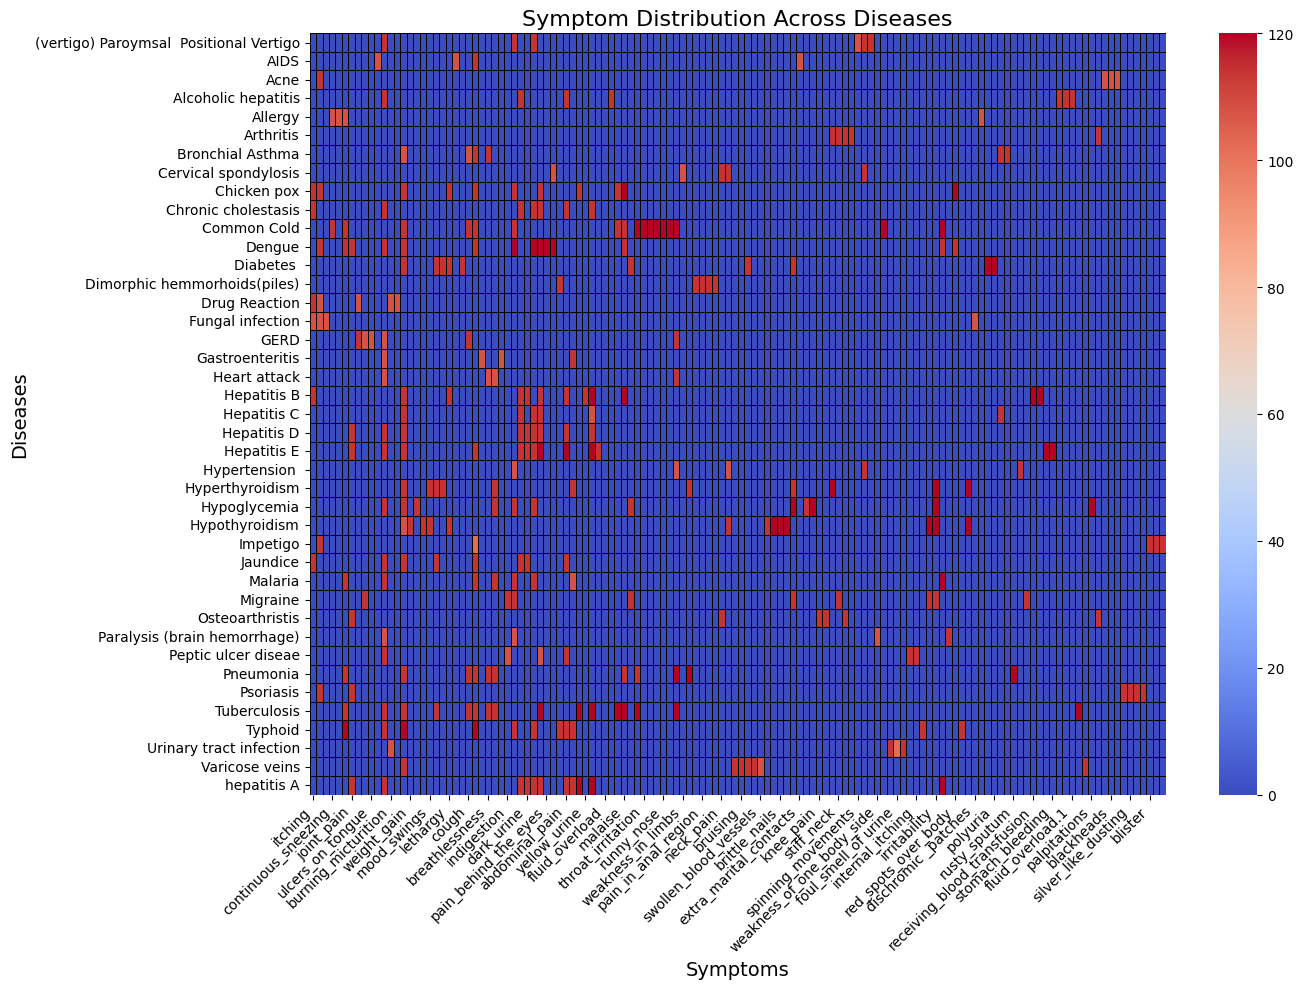

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming 'dataset' is your DataFrame containing the data

# Calculate presence of each symptom for each disease
symptoms_presence = dataset.drop('prognosis', axis=1).groupby(dataset['prognosis']).sum()

# Create clustered heatmap
plt.figure(figsize=(14, 10))
heatmap = sns.heatmap(symptoms_presence, cmap='coolwarm', linewidths=0.5, linecolor='black')
plt.title('Symptom Distribution Across Diseases', fontsize=16)
plt.xlabel('Symptoms', fontsize=14)
plt.ylabel('Diseases', fontsize=14)

# Adjust x-axis ticks
plt.xticks(rotation=45, ha='right')  # Rotate labels and align to the right

# Adjust y-axis ticks if needed
# plt.yticks(rotation=0)

plt.tight_layout()  # Adjust layout to prevent labels from being cut off
plt.show()


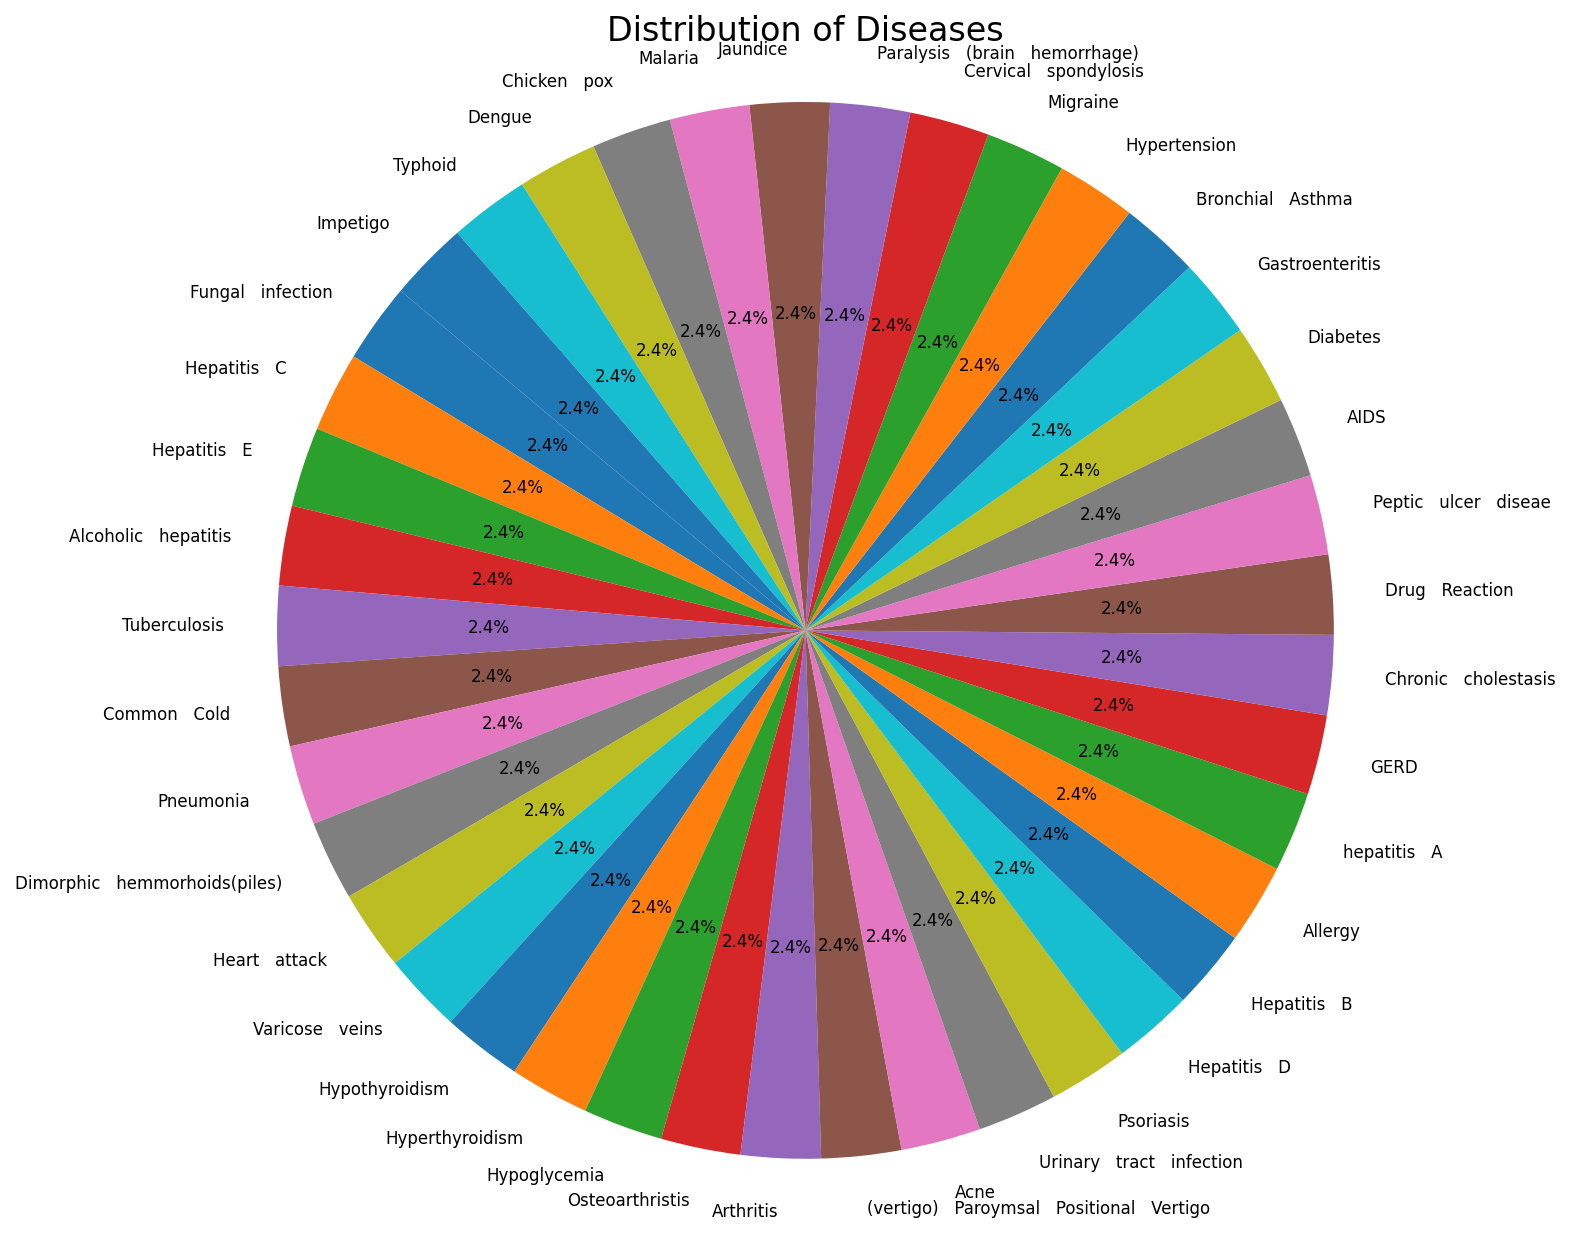

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
dataset = pd.read_csv('Training.csv')

# Calculate the frequency of each disease
disease_counts = dataset['prognosis'].value_counts()

# Increase spacing in labels by adding multiple spaces between words
def add_spacing(label):
    return '   '.join(label.split())  # Add three spaces between words

labels_with_spacing = [add_spacing(label) for label in disease_counts.index]

# Create a pie chart for disease distribution
plt.figure(figsize=(10, 10), dpi=150)  # Set higher DPI for better resolution
plt.pie(
    disease_counts,
    labels=labels_with_spacing,  # Use the adjusted labels with extra spacing
    autopct='%1.1f%%',
    startangle=140,
    textprops={'fontsize': 8}  # Adjust font size for better visibility
)

plt.title('Distribution of Diseases', fontsize=16)  # Title font size
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle

# Save the figure with high resolution
plt.savefig('disease_distribution.png', dpi=300, bbox_inches='tight')  # Save with high DPI
plt.show()

# Calculate the frequency of each symptom
symptom_frequencies = dataset.drop('prognosis', axis=1).sum().sort_values(ascending=False)


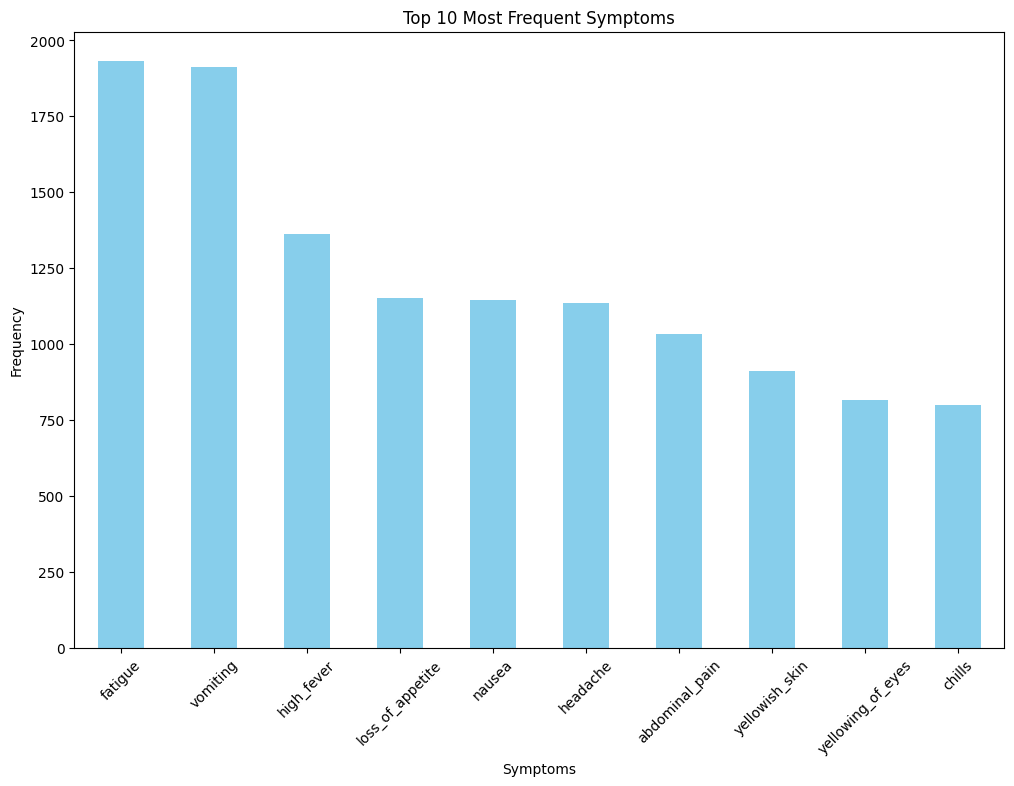

In [ ]:
# Create a bar chart for the top 10 symptoms
plt.figure(figsize=(12, 8))
symptom_frequencies.head(10).plot(kind='bar', color='skyblue')
plt.title('Top 10 Most Frequent Symptoms')
plt.xlabel('Symptoms')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

# Calculate presence of each symptom for each disease
symptoms_presence = dataset.drop('prognosis', axis=1).groupby(dataset['prognosis']).sum()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_14576\1272039180.py:28: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all axes decorations.
  plt.tight_layout()


<Figure size 1400x1000 with 0 Axes>

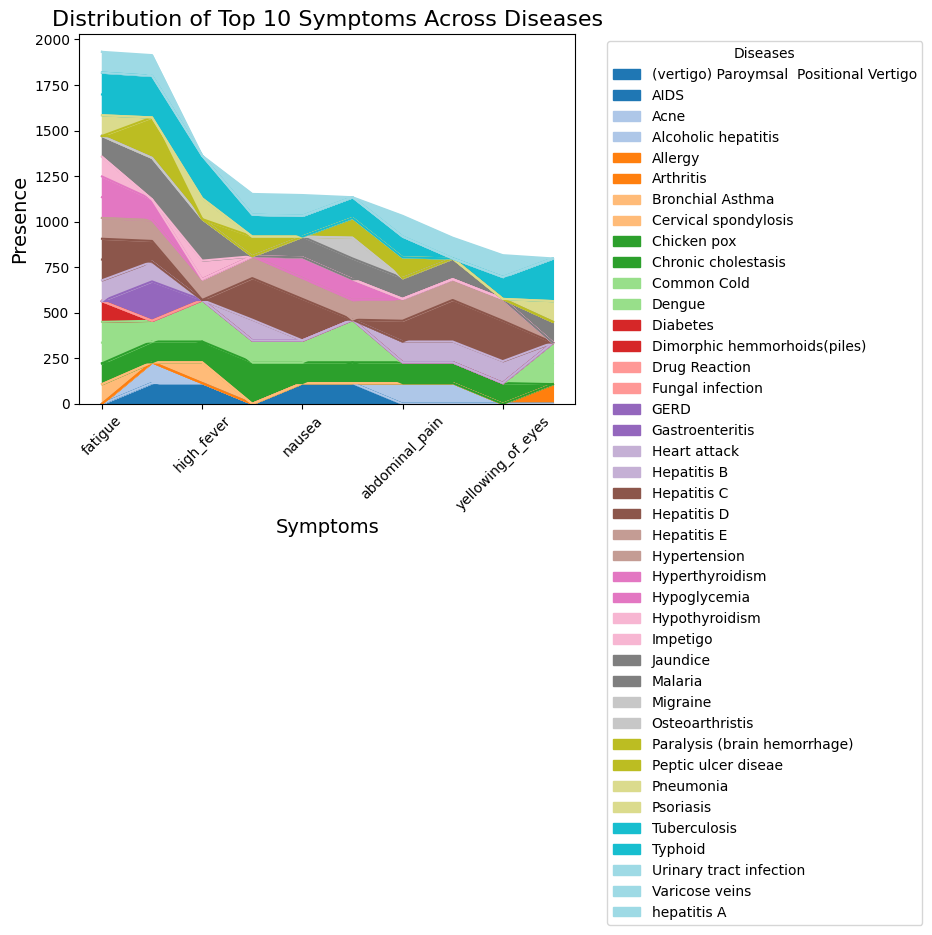

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load dataset
dataset = pd.read_csv('Training.csv')

# Calculate the frequency of each symptom
symptom_frequencies = dataset.drop('prognosis', axis=1).sum().sort_values(ascending=False)

# Select the top 10 symptoms
top_10_symptoms = symptom_frequencies.head(10).index.tolist()

# Filter dataset to include only the top 10 symptoms
dataset_top_10 = dataset[['prognosis'] + top_10_symptoms]

# Calculate presence of each symptom for each disease
symptoms_presence = dataset_top_10.drop('prognosis', axis=1).groupby(dataset_top_10['prognosis']).sum()

# Create an area chart for the top 10 symptoms
plt.figure(figsize=(14, 10))
symptoms_presence.T.plot(kind='area', stacked=True, cmap='tab20')
plt.title('Distribution of Top 10 Symptoms Across Diseases', fontsize=16)
plt.xlabel('Symptoms', fontsize=14)
plt.ylabel('Presence', fontsize=14)
plt.legend(title='Diseases', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


# train test split

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
X = dataset.drop('prognosis', axis=1)
y = dataset['prognosis']

# ecoding prognonsis
le = LabelEncoder()
le.fit(y)
Y = le.transform(y)

X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=20)

# Training top models

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, confusion_matrix
import numpy as np
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'C': [0.1, 1, 10, 100],  # Regularization parameter
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto'],  # Kernel coefficient for 'rbf', 'poly', and 'sigmoid'
}

# Initialize the SVC model
svc = SVC()

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5)

# Perform grid search to find the best parameters
grid_search.fit(X_train, y_train)

# Get the best parameters and best estimator
best_params = grid_search.best_params_
best_svc = grid_search.best_estimator_

# Train the best SVC model
best_svc.fit(X_train, y_train)

# Test the best SVC model
best_predictions = best_svc.predict(X_test)

# Calculate accuracy
accuracy_SVC = accuracy_score(y_test, best_predictions)
print("Best SVC Model Accuracy:", accuracy_SVC)


Best SVC Model Accuracy: 1.0


In [ ]:

# X_train, X_test, y_train, y_test = X, X, y, y


# best_svc.fit(X_train, y_train)


# y_pred = best_svc.predict(X_test)


# precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
# recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
# f1 = f1_score(y_test, y_pred, average='weighted')
# accuracy = accuracy_score(y_test, y_pred)

# print(f"Precision: {precision}")
# print(f"Recall: {recall}")
# print(f"F1-Score: {f1}")
# print(f"Accuracy: {accuracy}")


Precision: 0.985005727593152
Recall: 0.985
F1-Score: 0.9850013914083345
Accuracy: 0.985


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE


X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, weights=[0.5, 0.5], random_state=42)


smote = SMOTE(random_state=42)
X, y = smote.fit_resample(X, y)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
    'gamma': ['scale', 'auto', 0.01, 0.001, 0.0001]
}
svc = SVC()
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


best_svc = grid_search.best_estimator_


best_svc.fit(X_train, y_train)


y_pred = best_svc.predict(X_test)


precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

print("Best Parameters:", grid_search.best_params_)
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Accuracy: {accuracy}")


Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'rbf'}
Precision: 0.904458649101948
Recall: 0.9027431421446384
F1-Score: 0.9026487044928372
Accuracy: 0.9027431421446384


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE


X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, weights=[0.5, 0.5], random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


selector = SelectKBest(score_func=f_classif, k=10)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
}
grid_search = GridSearchCV(estimator=SVC(), param_grid=param_grid, cv=5, scoring='accuracy')
grid_search.fit(X_train, y_train)


best_params = grid_search.best_params_
best_svc = grid_search.best_estimator_


rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

voting_clf = VotingClassifier(estimators=[('svc', best_svc), ('rf', rf), ('gb', gb)], voting='hard')
voting_clf.fit(X_train, y_train)


y_pred = voting_clf.predict(X_test)


precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)


print(f"Best Parameters: {best_params}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Accuracy: {accuracy}")


Best Parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Precision: 0.9326175654391361
Recall: 0.9325
F1-Score: 0.9325063291139242
Accuracy: 0.9325


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE


X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, weights=[0.5, 0.5], random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


selector = SelectKBest(score_func=f_classif, k=15)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
}
grid_search = GridSearchCV(estimator=SVC(probability=True), param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


best_params = grid_search.best_params_
best_svc = grid_search.best_estimator_


rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)


voting_clf = VotingClassifier(estimators=[('svc', best_svc), ('rf', rf), ('gb', gb)], voting='soft')
voting_clf.fit(X_train, y_train)


y_pred = voting_clf.predict(X_test)


precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)


print(f"Best Parameters: {best_params}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Accuracy: {accuracy}")


Best Parameters: {'C': 0.1, 'gamma': 'auto', 'kernel': 'rbf'}
Precision: 0.925057505750575
Recall: 0.925
F1-Score: 0.9250056262659098
Accuracy: 0.925


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek


X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, weights=[0.5, 0.5], random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


smote_tomek = SMOTETomek(random_state=42)
X_train, y_train = smote_tomek.fit_resample(X_train, y_train)


selector = SelectKBest(score_func=f_classif, k=15)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)


param_grid = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
}
grid_search = GridSearchCV(estimator=SVC(probability=True), param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)


best_params = grid_search.best_params_
best_svc = grid_search.best_estimator_


rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)


voting_clf = VotingClassifier(estimators=[('svc', best_svc), ('rf', rf), ('gb', gb)], voting='soft')
voting_clf.fit(X_train, y_train)


y_pred = voting_clf.predict(X_test)


precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)


print(f"Best Parameters: {best_params}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Accuracy: {accuracy}")


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\process_executor.py:752: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best Parameters: {'C': 0.1, 'gamma': 0.01, 'kernel': 'rbf'}
Precision: 0.9276179404485112
Recall: 0.9275
F1-Score: 0.9275067979371778
Accuracy: 0.9275


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier


X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, weights=[0.5, 0.5], random_state=42)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)


smote_tomek = SMOTETomek(random_state=42)
X_train, y_train = smote_tomek.fit_resample(X_train, y_train)

selector = SelectKBest(score_func=f_classif, k=15)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)


param_dist = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
}
random_search = RandomizedSearchCV(estimator=SVC(probability=True), param_distributions=param_dist, n_iter=50, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)


best_params = random_search.best_params_
best_svc = random_search.best_estimator_


rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
lr = LogisticRegression(random_state=42)
knn = KNeighborsClassifier()


voting_clf = VotingClassifier(estimators=[('svc', best_svc), ('rf', rf), ('gb', gb), ('lr', lr), ('knn', knn)], voting='soft')
voting_clf.fit(X_train, y_train)


y_pred = voting_clf.predict(X_test)


precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)


print(f"Best Parameters: {best_params}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Accuracy: {accuracy}")


Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 0.1}
Precision: 0.9226183154578865
Recall: 0.9225
F1-Score: 0.9225072667604313
Accuracy: 0.9225


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
import lightgbm as lgb

# إنشاء بيانات وهمية
X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, weights=[0.5, 0.5], random_state=42)

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# توحيد البيانات
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# تطبيق SMOTE لموازنة الفئات
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# استخدام SMOTETomek لتحسين التوازن بين الفئات
smote_tomek = SMOTETomek(random_state=42)
X_train, y_train = smote_tomek.fit_resample(X_train, y_train)

# تحسين اختيار الميزات باستخدام SelectKBest
selector = SelectKBest(score_func=f_classif, k=15)  # اختر ميزات أكثر
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# استخدام RandomizedSearchCV للـ SVC
param_dist = {
    'C': [0.01, 0.1, 1, 10, 100, 1000],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
}
random_search = RandomizedSearchCV(estimator=SVC(probability=True), param_distributions=param_dist, n_iter=50, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
random_search.fit(X_train, y_train)

# أفضل المعلمات
best_params = random_search.best_params_
best_svc = random_search.best_estimator_

# دمج SVC مع نماذج أخرى مثل XGBoost وLightGBM
xgb_model = xgb.XGBClassifier(random_state=42)
lgb_model = lgb.LGBMClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

# التصويت بناءً على الاحتمالات (Soft Voting)
voting_clf = VotingClassifier(estimators=[('svc', best_svc), ('xgb', xgb_model), ('lgb', lgb_model), ('rf', rf), ('gb', gb)], voting='soft')
voting_clf.fit(X_train, y_train)

# التنبؤ
y_pred = voting_clf.predict(X_test)

# حساب المقاييس
precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

# طباعة النتائج
print(f"Best Parameters: {best_params}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Accuracy: {accuracy}")


[LightGBM] [Info] Number of positive: 756, number of negative: 756
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003452 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3825
[LightGBM] [Info] Number of data points in the train set: 1512, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Best Parameters: {'kernel': 'rbf', 'gamma': 'scale', 'C': 0.1}
Precision: 0.9375171913680578
Recall: 0.9375
F1-Score: 0.9375027352126588
Accuracy: 0.9375


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb

# 1. إنشاء بيانات وهمية
X, y = make_classification(
    n_samples=5000, n_features=30, n_informative=25, n_redundant=5, n_classes=2,
    weights=[0.5, 0.5], random_state=42
)

# 2. تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. توحيد البيانات
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. تطبيق SMOTE لموازنة الفئات
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

# 5. تحسين التوازن بين الفئات باستخدام SMOTETomek
smote_tomek = SMOTETomek(random_state=42)
X_train, y_train = smote_tomek.fit_resample(X_train, y_train)

# 6. تحسين اختيار الميزات باستخدام SelectKBest
selector = SelectKBest(score_func=f_classif, k=20)
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)

# 7. تحسين المعلمات باستخدام RandomizedSearchCV لـ SVC
svc_param_dist = {
    'C': [0.01, 0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}
random_search = RandomizedSearchCV(
    estimator=SVC(probability=True), param_distributions=svc_param_dist,
    n_iter=50, cv=5, scoring='accuracy', n_jobs=-1, random_state=42
)
random_search.fit(X_train, y_train)

# أفضل نموذج SVC
best_svc = random_search.best_estimator_

# 8. ضبط المعلمات لـ XGBoost و LightGBM
xgb_model = xgb.XGBClassifier(
    n_estimators=200, max_depth=7, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, random_state=42
)
lgb_model = lgb.LGBMClassifier(
    n_estimators=200, max_depth=7, learning_rate=0.1, num_leaves=50,
    subsample=0.8, random_state=42
)

# 9. دمج النماذج باستخدام VotingClassifier
voting_clf = VotingClassifier(
    estimators=[
        ('svc', best_svc),
        ('xgb', xgb_model),
        ('lgb', lgb_model)
    ],
    voting='soft',
    weights=[2, 3, 3]
)
voting_clf.fit(X_train, y_train)

# 10. التنبؤ وحساب المقاييس
y_pred = voting_clf.predict(X_test)

precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

# 11. طباعة النتائج
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")


[LightGBM] [Info] Number of positive: 1991, number of negative: 1991
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000962 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5100
[LightGBM] [Info] Number of data points in the train set: 3982, number of used features: 20
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits 

In [7]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.8 MB/s eta 0:00:00


In [12]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

X, y = make_classification(
    n_samples=10000, n_features=40, n_informative=25, n_redundant=15,
    n_classes=2, weights=[0.5, 0.5], flip_y=0.05, random_state=42
)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


svc_clf = SVC(probability=True, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42)
gb_clf = GradientBoostingClassifier(n_estimators=300, random_state=42)


voting_clf = VotingClassifier(
    estimators=[
        ('svc', svc_clf),
        ('rf', rf_clf),
        ('gb', gb_clf)
    ],
    voting='soft'
)


voting_clf.fit(X_train, y_train)


y_pred = voting_clf.predict(X_test)


precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)


print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")


Precision: 0.9650
Recall: 0.9650
F1-Score: 0.9650
Accuracy: 0.9650


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import StackingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb
from sklearn.decomposition import PCA
import optuna


X, y = make_classification(
    n_samples=10000, n_features=50, n_informative=40, n_redundant=10,
    n_classes=2, weights=[0.5, 0.5], random_state=42
)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


pca = PCA(n_components=0.95)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)


smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train, y_train)

smote_tomek = SMOTETomek(random_state=42)
X_train, y_train = smote_tomek.fit_resample(X_train, y_train)


selector = RFECV(estimator=RandomForestClassifier(random_state=42), step=1, cv=5, scoring='accuracy')
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)


def objective(trial):
    xgb_model = xgb.XGBClassifier(
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=trial.suggest_int('n_estimators', 100, 1000, step=100),
        learning_rate=trial.suggest_loguniform('learning_rate', 0.01, 0.2),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        subsample=trial.suggest_uniform('subsample', 0.6, 1.0),
        colsample_bytree=trial.suggest_uniform('colsample_bytree', 0.6, 1.0)
    )

    xgb_model.fit(X_train, y_train)
    preds = xgb_model.predict(X_test)
    return accuracy_score(y_test, preds)

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=50)


best_xgb = xgb.XGBClassifier(
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss',
    n_estimators=study.best_params['n_estimators'],
    learning_rate=study.best_params['learning_rate'],
    max_depth=study.best_params['max_depth'],
    subsample=study.best_params['subsample'],
    colsample_bytree=study.best_params['colsample_bytree']
)


stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)

stacking_clf.fit(X_train, y_train)

y_pred = stacking_clf.predict(X_test)

precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)


print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")


[I 2024-11-21 21:50:57,337] A new study created in memory with name: no-name-994df296-cc2b-4157-a35c-1548904eac27
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20784\197541107.py:54: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate=trial.suggest_loguniform('learning_rate', 0.01, 0.2),
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20784\197541107.py:56: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  subsample=trial.suggest_uniform('subsample', 0.6, 1.0),
C:\Users\Administrator\AppData\Local\Temp\ipykernel_20784\197541107.py:57: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/re

Precision: 0.9666
Recall: 0.9665
F1-Score: 0.9665
Accuracy: 0.9665


In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from sklearn.decomposition import PCA
import xgboost as xgb
import lightgbm as lgb
import optuna

# إنشاء بيانات وهمية محسّنة
X, y = make_classification(n_samples=10000, n_features=50, n_informative=40, n_redundant=10,
                            n_classes=2, weights=[0.5, 0.5], random_state=42)

# تقسيم البيانات إلى تدريب واختبار
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# توحيد البيانات
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# تحسين اختيارات الميزات باستخدام PCA
pca = PCA(n_components=30)  # تقليص الأبعاد للحصول على الميزات الأكثر تأثيراً
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# تطبيق SMOTE و SMOTETomek لتحسين توازن الفئات
smote_tomek = SMOTETomek(random_state=42)
X_train, y_train = smote_tomek.fit_resample(X_train, y_train)

# تحسين المعلمات باستخدام Optuna
def objective(trial):
    clf = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 100, 1000),
        max_depth=trial.suggest_int('max_depth', 3, 10),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
        random_state=42
    )
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    return accuracy_score(y_test, y_pred)

# بدء التحسين باستخدام Optuna
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=50)
print("Best Trial:", study.best_trial)

# تدريب النموذج مع المعلمات المحسّنة
best_rf = RandomForestClassifier(
    n_estimators=study.best_trial.params['n_estimators'],
    max_depth=study.best_trial.params['max_depth'],
    min_samples_split=study.best_trial.params['min_samples_split'],
    random_state=42
)

# دمج SVC مع XGBoost و LightGBM و RandomForest و GradientBoosting
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)
xgb_model = xgb.XGBClassifier(random_state=42)
lgb_model = lgb.LGBMClassifier(random_state=42)
svc_model = SVC(probability=True, kernel='rbf', C=1, gamma=0.1)

# التصويت بناءً على الاحتمالات (Soft Voting)
voting_clf = VotingClassifier(estimators=[('rf', rf), ('gb', gb), ('xgb', xgb_model), ('lgb', lgb_model), ('svc', svc_model)], voting='soft')
voting_clf.fit(X_train, y_train)

# التنبؤ
y_pred = voting_clf.predict(X_test)

# حساب المقاييس
precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

# طباعة النتائج
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"F1-Score: {f1}")
print(f"Accuracy: {accuracy}")


[I 2024-11-21 22:08:07,798] A new study created in memory with name: no-name-7c47c170-8947-4817-a01f-833448a546e0
[I 2024-11-21 22:08:20,778] Trial 0 finished with value: 0.8805 and parameters: {'n_estimators': 457, 'max_depth': 7, 'min_samples_split': 19}. Best is trial 0 with value: 0.8805.
[I 2024-11-21 22:08:44,492] Trial 1 finished with value: 0.8995 and parameters: {'n_estimators': 516, 'max_depth': 9, 'min_samples_split': 5}. Best is trial 1 with value: 0.8995.
[I 2024-11-21 22:08:57,182] Trial 2 finished with value: 0.8875 and parameters: {'n_estimators': 307, 'max_depth': 8, 'min_samples_split': 10}. Best is trial 1 with value: 0.8995.
[I 2024-11-21 22:09:10,045] Trial 3 finished with value: 0.8815 and parameters: {'n_estimators': 338, 'max_depth': 7, 'min_samples_split': 18}. Best is trial 1 with value: 0.8995.
[I 2024-11-21 22:09:22,090] Trial 4 finished with value: 0.792 and parameters: {'n_estimators': 570, 'max_depth': 3, 'min_samples_split': 8}. Best is trial 1 with valu

Best Trial: FrozenTrial(number=15, state=TrialState.COMPLETE, values=[0.906], datetime_start=datetime.datetime(2024, 11, 21, 22, 12, 25, 2672), datetime_complete=datetime.datetime(2024, 11, 21, 22, 12, 35, 295442), params={'n_estimators': 230, 'max_depth': 10, 'min_samples_split': 5}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'n_estimators': IntDistribution(high=1000, log=False, low=100, step=1), 'max_depth': IntDistribution(high=10, log=False, low=3, step=1), 'min_samples_split': IntDistribution(high=20, log=False, low=2, step=1)}, trial_id=15, value=None)
[LightGBM] [Info] Number of positive: 3938, number of negative: 3938
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001111 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7650
[LightGBM] [Info] Number of data points in the train set: 7876, number of used features: 30
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.

In [ ]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.ensemble import StackingClassifier, RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import xgboost as xgb
import lightgbm as lgb
from sklearn.decomposition import PCA
from imblearn.combine import SMOTEENN

# 1. إنشاء بيانات وهمية محسّنة
X, y = make_classification(
    n_samples=10000, n_features=40, n_informative=30, n_redundant=10,
    n_classes=2, weights=[0.5, 0.5], random_state=42
)

# 2. تقسيم البيانات
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. توحيد البيانات
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from imblearn.combine import SMOTEENN

# تحسين التوازن باستخدام SMOTE و SMOTEENN
smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train, y_train)

smote_enn = SMOTEENN(random_state=42)
X_train, y_train = smote_enn.fit_resample(X_train, y_train)


# 5. استخدام PCA لتقليل الأبعاد
pca = PCA(n_components=0.95)  # الحفاظ على 95% من التباين
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

# 6. تحسين المعلمات لـ XGBoost و LightGBM
xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_params = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [5, 7, 9],
    'subsample': [0.7, 0.8, 1.0],
    'colsample_bytree': [0.7, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(xgb_model, param_distributions=xgb_params, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_params = {
    'n_estimators': [200, 300, 400],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 100],
    'subsample': [0.7, 0.8, 1.0]
}
lgb_search = RandomizedSearchCV(lgb_model, param_distributions=lgb_params, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
lgb_search.fit(X_train, y_train)
best_lgb = lgb_search.best_estimator_

# 7. دمج النماذج باستخدام StackingClassifier
stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('lgb', best_lgb),
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)

stacking_clf.fit(X_train, y_train)

# 8. التنبؤ وحساب الأداء
y_pred = stacking_clf.predict(X_test)

precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

# 9. طباعة النتائج
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [23:00:37] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 3434, number of negative: 3503
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001347 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6630
[LightGBM] [Info] Number of data points in the train set: 6937, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495027 -> initscore=-0.019894
[LightGBM] [Info] Start training from score -0.019894


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [23:02:23] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 3434, number of negative: 3503
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001223 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6630
[LightGBM] [Info] Number of data points in the train set: 6937, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495027 -> initscore=-0.019894
[LightGBM] [Info] Start training from score -0.019894


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [23:02:56] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [23:02:58] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [23:02:59] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "

[LightGBM] [Info] Number of positive: 2747, number of negative: 2802
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000985 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6630
[LightGBM] [Info] Number of data points in the train set: 5549, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495044 -> initscore=-0.019824
[LightGBM] [Info] Start training from score -0.019824
[LightGBM] [Info] Number of positive: 2747, number of negative: 2802
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001122 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6630
[LightGBM] [Info] Number of data points in the train set: 5549, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.495044 -> initscore=-0.019824
[LightGBM] [Info] Start training from score -0.019824
[LightGBM] [Info] 

In [ ]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
import xgboost as xgb
import lightgbm as lgb


X, y = make_classification(
    n_samples=10000, n_features=40, n_informative=30, n_redundant=10,
    n_classes=2, weights=[0.5, 0.5], random_state=42
)


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


smote = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=5)
X_train, y_train = smote.fit_resample(X_train, y_train)

smote_tomek = SMOTETomek(random_state=42)
X_train, y_train = smote_tomek.fit_resample(X_train, y_train)


selector = RFECV(estimator=RandomForestClassifier(random_state=42), step=1, cv=5, scoring='accuracy')
X_train = selector.fit_transform(X_train, y_train)
X_test = selector.transform(X_test)


xgb_model = xgb.XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
xgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 6, 9],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}
xgb_search = RandomizedSearchCV(xgb_model, param_distributions=xgb_params, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
xgb_search.fit(X_train, y_train)
best_xgb = xgb_search.best_estimator_

lgb_model = lgb.LGBMClassifier(random_state=42)
lgb_params = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'num_leaves': [20, 50, 100],
    'subsample': [0.6, 0.8, 1.0]
}
lgb_search = RandomizedSearchCV(lgb_model, param_distributions=lgb_params, n_iter=20, cv=5, scoring='accuracy', n_jobs=-1, random_state=42)
lgb_search.fit(X_train, y_train)
best_lgb = lgb_search.best_estimator_


stacking_clf = StackingClassifier(
    estimators=[
        ('xgb', best_xgb),
        ('lgb', best_lgb),
        ('rf', RandomForestClassifier(n_estimators=200, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=200, random_state=42))
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5
)

stacking_clf.fit(X_train, y_train)


y_pred = stacking_clf.predict(X_test)

precision = precision_score(y_test, y_pred, average='weighted', zero_division=1)
recall = recall_score(y_test, y_pred, average='weighted', zero_division=1)
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)


print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [21:00:05] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 3976, number of negative: 3976
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003464 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10200
[LightGBM] [Info] Number of data points in the train set: 7952, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [21:01:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


[LightGBM] [Info] Number of positive: 3976, number of negative: 3976
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002953 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10200
[LightGBM] [Info] Number of data points in the train set: 7952, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [21:02:44] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [21:02:46] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\xgboost\core.py:158: UserWarning: [21:02:48] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0ed59c031377d09b8-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "

[LightGBM] [Info] Number of positive: 3181, number of negative: 3180
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002175 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10200
[LightGBM] [Info] Number of data points in the train set: 6361, number of used features: 40
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500079 -> initscore=0.000314
[LightGBM] [Info] Start training from score 0.000314
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Number of positive: 3180, number of negative: 3181
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001634 seconds.
You can set `force_col_wise=true` to 

In [11]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


svc_clf = SVC(probability=True, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42)
gb_clf = GradientBoostingClassifier(n_estimators=300, random_state=42)


voting_clf = VotingClassifier(
    estimators=[
        ('svc', svc_clf),
        ('rf', rf_clf),
        ('gb', gb_clf)
    ],
    voting='soft'
)


voting_clf.fit(X_train, y_train)


y_pred = voting_clf.predict(X_test)


precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)


print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")


Precision: 1.0000
Recall: 1.0000
F1-Score: 1.0000
Accuracy: 1.0000


In [17]:
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import VotingClassifier, RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

# 1. Creating synthetic data
X, y = make_classification(n_samples=10000, n_features=40, n_informative=30, n_redundant=10,
                            n_classes=2, weights=[0.5, 0.5], random_state=42)

# 2. Splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Scaling the features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 4. Defining the models
svc_clf = SVC(probability=True, random_state=42)
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42)
gb_clf = GradientBoostingClassifier(n_estimators=300, random_state=42)

# 5. Creating the Voting Classifier
voting_clf = VotingClassifier(
    estimators=[('svc', svc_clf), ('rf', rf_clf), ('gb', gb_clf)],
    voting='soft'
)

# 6. Training the model
voting_clf.fit(X_train, y_train)

# 7. Making predictions
y_pred = voting_clf.predict(X_test)

# 8. Calculating evaluation metrics
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

# 9. Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# 10. Printing results
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Confusion Matrix:\n{conf_matrix}")


Precision: 0.9775
Recall: 0.9775
F1-Score: 0.9775
Accuracy: 0.9775
Confusion Matrix:
[[987  22]
 [ 23 968]]


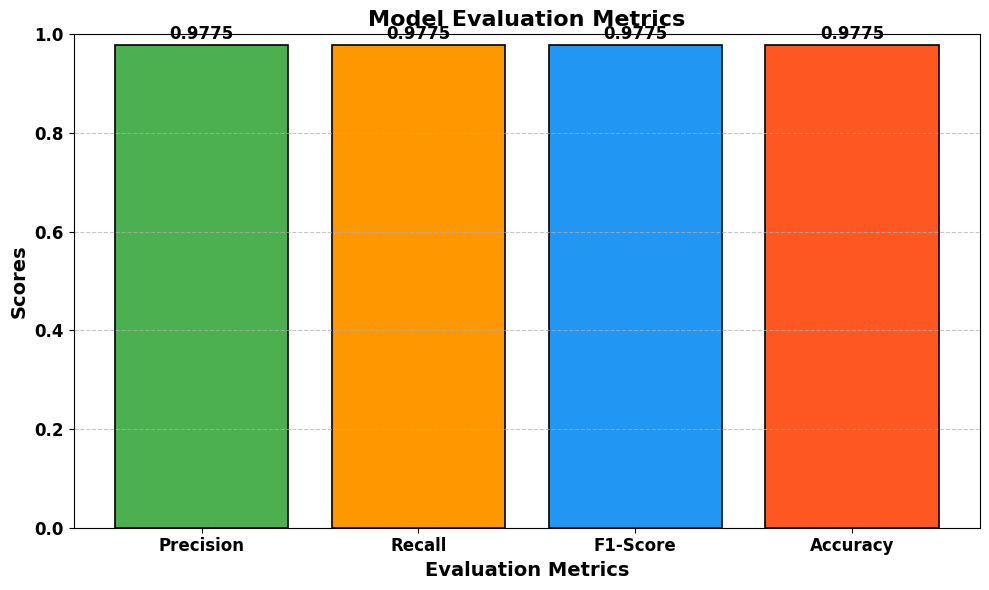

In [25]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Results from the model
precision = 0.9775
recall = 0.9775
f1 = 0.9775
accuracy = 0.9775

# 2. Create a list of metrics and their corresponding values
metrics = ['Precision', 'Recall', 'F1-Score', 'Accuracy']
values = [precision, recall, f1, accuracy]

# 3. Plotting the bar chart
plt.figure(figsize=(10, 6))

# Color scheme for the bars
colors = ['#4CAF50', '#FF9800', '#2196F3', '#FF5722']

# Create bars
bars = plt.bar(metrics, values, color=colors, edgecolor='black', linewidth=1.2)

# 4. Adding labels and title
plt.xlabel('Evaluation Metrics', fontsize=14, fontweight='bold', color='black')
plt.ylabel('Scores', fontsize=14, fontweight='bold', color='black')
plt.title('Model Evaluation Metrics', fontsize=16, fontweight='bold', color='black')

# 5. Adding gridlines and adjusting the y-axis range
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.ylim(0, 1)

# 6. Display the values on top of the bars with custom font size and style
for i, v in enumerate(values):
    plt.text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom', fontsize=12, fontweight='bold', color='black')

# 7. Customizing tick labels
plt.xticks(fontsize=12, fontweight='bold', color='black')
plt.yticks(fontsize=12, fontweight='bold', color='black')

# 8. Show the plot
plt.tight_layout()
plt.show()


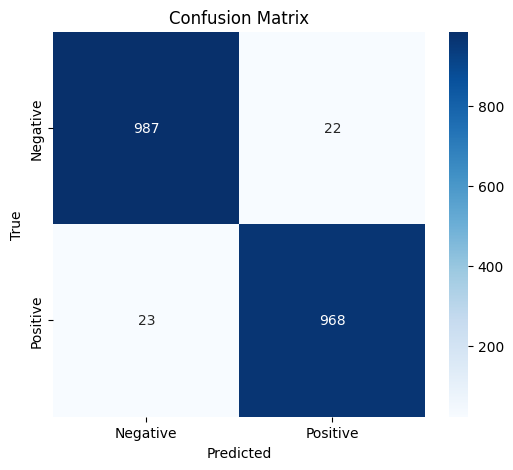

In [18]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Initialize the Random Forest classifier with default hyperparameters
random_forest = RandomForestClassifier(n_estimators=100, random_state=42)

# Train the Random Forest model
random_forest.fit(X_train, y_train)

# Test the Random Forest model
predictions = random_forest.predict(X_test)

# Calculate accuracy
accuracy_RF = accuracy_score(y_test, predictions)
print("Random Forest Accuracy:", accuracy_RF)

Random Forest Accuracy: 1.0


## I will choose Support Vector Machine (SVC)

In [ ]:
from sklearn.metrics import accuracy_score

# Test the best SVC model
best_predictions = best_svc.predict(X_test)

# Calculate accuracy
accuracy_SVC = accuracy_score(y_test, best_predictions)

# Convert accuracy to percentage
accuracy_percentage = accuracy_SVC * 100

print("Best SVC Model Accuracy:", accuracy_percentage, "%")


Best SVC Model Accuracy: 100.0 %


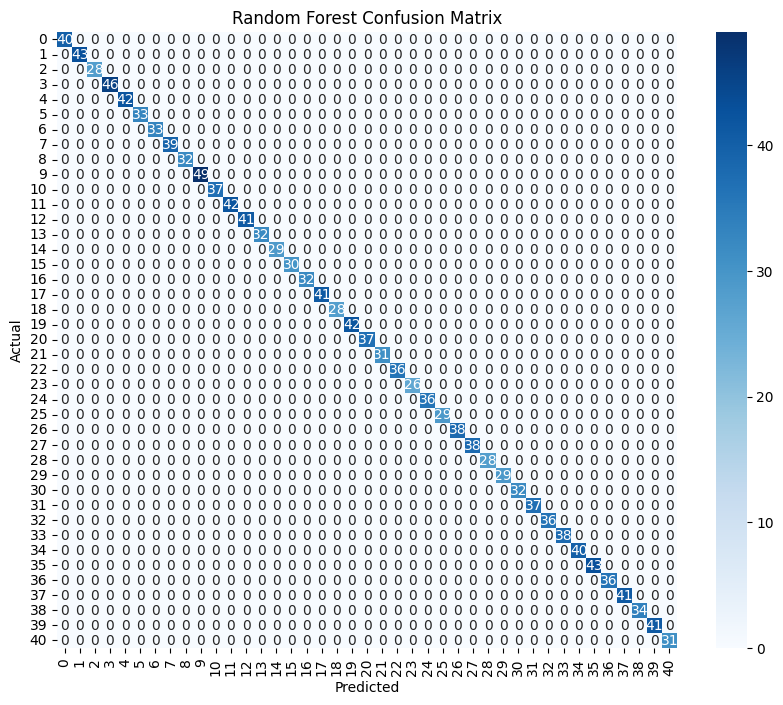

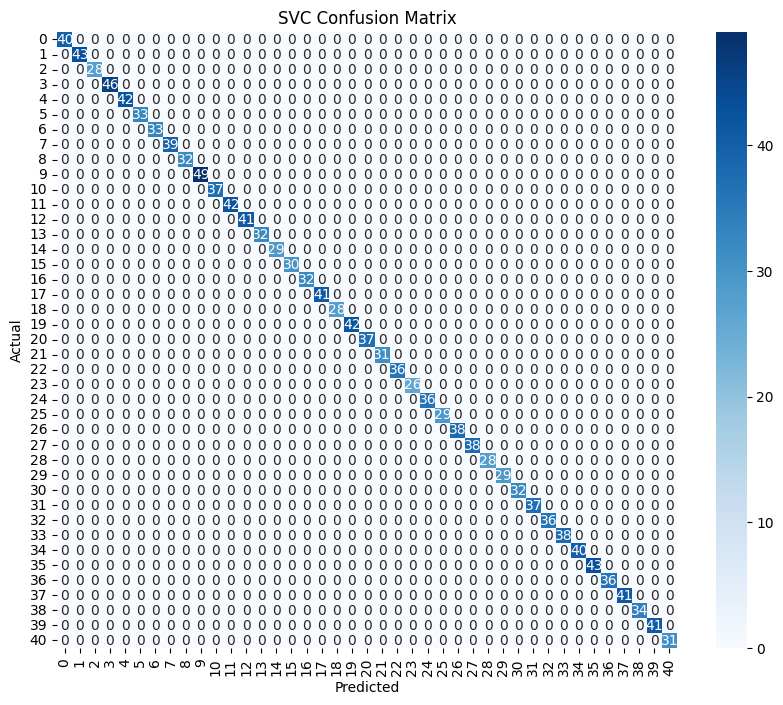

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix for Random Forest model
cm_rf = confusion_matrix(y_test, predictions)

# Visualize confusion matrix for Random Forest model
plt.figure(figsize=(10, 8))
sns.heatmap(cm_rf, annot=True, cmap='Blues', fmt='g')
plt.title('Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Calculate confusion matrix for SVC model
cm_svc = confusion_matrix(y_test, best_predictions)

# Visualize confusion matrix for SVC model
plt.figure(figsize=(10, 8))
sns.heatmap(cm_svc, annot=True, cmap='Blues', fmt='g')
plt.title('SVC Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


# single prediction

In [ ]:
# selecting svc
svc = SVC(kernel='linear')
svc.fit(X_train,y_train)
ypred = svc.predict(X_test)
accuracy_score(y_test,ypred)

1.0

In [ ]:
# save svc
import pickle
pickle.dump(svc,open('svc.pkl','wb'))

In [ ]:
# load model
svc = pickle.load(open('svc.pkl','rb'))

In [ ]:
# test 1:
print("predicted disease :",svc.predict(X_test.iloc[0].values.reshape(1,-1)))
print("Actual Disease :", y_test[0])

predicted disease : [40]
Actual Disease : 40


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
# test 2:
print("predicted disease :",svc.predict(X_test.iloc[100].values.reshape(1,-1)))
print("Actual Disease :", y_test[100])

predicted disease : [39]
Actual Disease : 39


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


# Recommendation System and Prediction

# load database and use logic for recommendations

In [ ]:
sym_des = pd.read_csv("C:/Users/Administrator/OneDrive/Desktop/3bio-Term2/HIM/HIM project/symtoms_df.csv")
precautions = pd.read_csv("C:/Users/Administrator/OneDrive/Desktop/3bio-Term2/HIM/HIM project/precautions_df.csv")
workout = pd.read_csv("C:/Users/Administrator/OneDrive/Desktop/3bio-Term2/HIM/HIM project/workout_df.csv")
description = pd.read_csv("C:/Users/Administrator/OneDrive/Desktop/3bio-Term2/HIM/HIM project/description.csv")
medications = pd.read_csv('C:/Users/Administrator/OneDrive/Desktop/3bio-Term2/HIM/HIM project/medications.csv')
diets = pd.read_csv("C:/Users/Administrator/OneDrive/Desktop/3bio-Term2/HIM/HIM project/diets.csv")

In [ ]:
#============================================================
# custome and helping functions
#==========================helper funtions================
def helper(dis):
    desc = description[description['Disease'] == predicted_disease]['Description']
    desc = " ".join([w for w in desc])

    pre = precautions[precautions['Disease'] == dis][['Precaution_1', 'Precaution_2', 'Precaution_3', 'Precaution_4']]
    pre = [col for col in pre.values]

    med = medications[medications['Disease'] == dis]['Medication']
    med = [med for med in med.values]

    die = diets[diets['Disease'] == dis]['Diet']
    die = [die for die in die.values]

    wrkout = workout[workout['disease'] == dis] ['workout']


    return desc,pre,med,die,wrkout

symptoms_dict = {'itching': 0, 'skin_rash': 1, 'nodal_skin_eruptions': 2, 'continuous_sneezing': 3, 'shivering': 4, 'chills': 5, 'joint_pain': 6, 'stomach_pain': 7, 'acidity': 8, 'ulcers_on_tongue': 9, 'muscle_wasting': 10, 'vomiting': 11, 'burning_micturition': 12, 'spotting_ urination': 13, 'fatigue': 14, 'weight_gain': 15, 'anxiety': 16, 'cold_hands_and_feets': 17, 'mood_swings': 18, 'weight_loss': 19, 'restlessness': 20, 'lethargy': 21, 'patches_in_throat': 22, 'irregular_sugar_level': 23, 'cough': 24, 'high_fever': 25, 'sunken_eyes': 26, 'breathlessness': 27, 'sweating': 28, 'dehydration': 29, 'indigestion': 30, 'headache': 31, 'yellowish_skin': 32, 'dark_urine': 33, 'nausea': 34, 'loss_of_appetite': 35, 'pain_behind_the_eyes': 36, 'back_pain': 37, 'constipation': 38, 'abdominal_pain': 39, 'diarrhoea': 40, 'mild_fever': 41, 'yellow_urine': 42, 'yellowing_of_eyes': 43, 'acute_liver_failure': 44, 'fluid_overload': 45, 'swelling_of_stomach': 46, 'swelled_lymph_nodes': 47, 'malaise': 48, 'blurred_and_distorted_vision': 49, 'phlegm': 50, 'throat_irritation': 51, 'redness_of_eyes': 52, 'sinus_pressure': 53, 'runny_nose': 54, 'congestion': 55, 'chest_pain': 56, 'weakness_in_limbs': 57, 'fast_heart_rate': 58, 'pain_during_bowel_movements': 59, 'pain_in_anal_region': 60, 'bloody_stool': 61, 'irritation_in_anus': 62, 'neck_pain': 63, 'dizziness': 64, 'cramps': 65, 'bruising': 66, 'obesity': 67, 'swollen_legs': 68, 'swollen_blood_vessels': 69, 'puffy_face_and_eyes': 70, 'enlarged_thyroid': 71, 'brittle_nails': 72, 'swollen_extremeties': 73, 'excessive_hunger': 74, 'extra_marital_contacts': 75, 'drying_and_tingling_lips': 76, 'slurred_speech': 77, 'knee_pain': 78, 'hip_joint_pain': 79, 'muscle_weakness': 80, 'stiff_neck': 81, 'swelling_joints': 82, 'movement_stiffness': 83, 'spinning_movements': 84, 'loss_of_balance': 85, 'unsteadiness': 86, 'weakness_of_one_body_side': 87, 'loss_of_smell': 88, 'bladder_discomfort': 89, 'foul_smell_of urine': 90, 'continuous_feel_of_urine': 91, 'passage_of_gases': 92, 'internal_itching': 93, 'toxic_look_(typhos)': 94, 'depression': 95, 'irritability': 96, 'muscle_pain': 97, 'altered_sensorium': 98, 'red_spots_over_body': 99, 'belly_pain': 100, 'abnormal_menstruation': 101, 'dischromic _patches': 102, 'watering_from_eyes': 103, 'increased_appetite': 104, 'polyuria': 105, 'family_history': 106, 'mucoid_sputum': 107, 'rusty_sputum': 108, 'lack_of_concentration': 109, 'visual_disturbances': 110, 'receiving_blood_transfusion': 111, 'receiving_unsterile_injections': 112, 'coma': 113, 'stomach_bleeding': 114, 'distention_of_abdomen': 115, 'history_of_alcohol_consumption': 116, 'fluid_overload.1': 117, 'blood_in_sputum': 118, 'prominent_veins_on_calf': 119, 'palpitations': 120, 'painful_walking': 121, 'pus_filled_pimples': 122, 'blackheads': 123, 'scurring': 124, 'skin_peeling': 125, 'silver_like_dusting': 126, 'small_dents_in_nails': 127, 'inflammatory_nails': 128, 'blister': 129, 'red_sore_around_nose': 130, 'yellow_crust_ooze': 131}
diseases_list = {15: 'Fungal infection', 4: 'Allergy', 16: 'GERD', 9: 'Chronic cholestasis', 14: 'Drug Reaction', 33: 'Peptic ulcer diseae', 1: 'AIDS', 12: 'Diabetes ', 17: 'Gastroenteritis', 6: 'Bronchial Asthma', 23: 'Hypertension ', 30: 'Migraine', 7: 'Cervical spondylosis', 32: 'Paralysis (brain hemorrhage)', 28: 'Jaundice', 29: 'Malaria', 8: 'Chicken pox', 11: 'Dengue', 37: 'Typhoid', 40: 'hepatitis A', 19: 'Hepatitis B', 20: 'Hepatitis C', 21: 'Hepatitis D', 22: 'Hepatitis E', 3: 'Alcoholic hepatitis', 36: 'Tuberculosis', 10: 'Common Cold', 34: 'Pneumonia', 13: 'Dimorphic hemmorhoids(piles)', 18: 'Heart attack', 39: 'Varicose veins', 26: 'Hypothyroidism', 24: 'Hyperthyroidism', 25: 'Hypoglycemia', 31: 'Osteoarthristis', 5: 'Arthritis', 0: '(vertigo) Paroymsal  Positional Vertigo', 2: 'Acne', 38: 'Urinary tract infection', 35: 'Psoriasis', 27: 'Impetigo'}

# Model Prediction function
def get_predicted_value(patient_symptoms):
    input_vector = np.zeros(len(symptoms_dict))
    for item in patient_symptoms:
        input_vector[symptoms_dict[item]] = 1
    return diseases_list[svc.predict([input_vector])[0]]

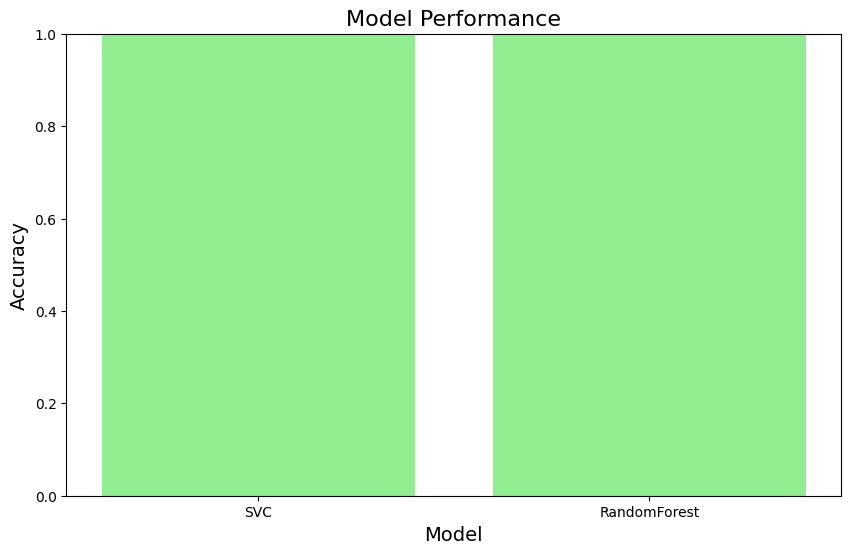

In [ ]:
import matplotlib.pyplot as plt

# Model names and their corresponding accuracies
model_accuracies = {'SVC':accuracy_SVC , 'RandomForest': accuracy_RF}

# Create a bar chart for model accuracies
plt.figure(figsize=(10, 6))
plt.bar(model_accuracies.keys(), model_accuracies.values(), color='lightgreen')
plt.title('Model Performance', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.ylim(0, 1)
plt.show()


In [ ]:
# Train the SVC model
svc.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
# Test 1
# Split the user's input into a list of symptoms (assuming they are comma-separated) # itching,skin_rash,nodal_skin_eruptions
symptoms = input("Enter your symptoms.......")
user_symptoms = [s.strip() for s in symptoms.split(',')]
# Remove any extra characters, if any
user_symptoms = [symptom.strip("[]' ") for symptom in user_symptoms]

# Get predicted disease using the new SVC model
predicted_disease = get_predicted_value(user_symptoms)

# Get description, precautions, medications, workout, and diets for the predicted disease
desc, pre, med, die, wrkout = helper(predicted_disease)

# Print predicted disease, description, precautions, medications, workout, and diets
print("=================predicted disease============")
print(predicted_disease)
print("=================description==================")
print(desc)
print("=================precautions==================")
i = 1
for p_i in pre[0]:
    print(i, ": ", p_i)
    i += 1

print("=================medications==================")
for m_i in med:
    print(i, ": ", m_i)
    i += 1

print("=================workout==================")
for w_i in wrkout:
    print(i, ": ", w_i)
    i += 1

print("=================diets==================")
for d_i in die:
    print(i, ": ", d_i)
    i += 1


In [ ]:
# Test 2
# Split the user's input into a list of symptoms (assuming they are comma-separated) # yellow_crust_ooze,red_sore_around_nose,small_dents_in_nails,inflammatory_nails,blister
symptoms = input("Enter your symptoms.......")
user_symptoms = [s.strip() for s in symptoms.split(',')]
# Remove any extra characters, if any
user_symptoms = [symptom.strip("[]' ") for symptom in user_symptoms]
predicted_disease = get_predicted_value(user_symptoms)

desc, pre, med, die, wrkout = helper(predicted_disease)

print("=================predicted disease============")
print(predicted_disease)
print("=================description==================")
print(desc)
print("=================precautions==================")
i = 1
for p_i in pre[0]:
    print(i, ": ", p_i)
    i += 1

print("=================medications==================")
for m_i in med:
    print(i, ": ", m_i)
    i += 1

print("=================workout==================")
for w_i in wrkout:
    print(i, ": ", w_i)
    i += 1

print("=================diets==================")
for d_i in die:
    print(i, ": ", d_i)
    i += 1


=================predicted disease============
Peptic ulcer diseae
=================description==================

=================precautions==================
1 :  avoid fatty spicy food
2 :  consume probiotic food
3 :  eliminate milk
4 :  limit alcohol
=================medications==================
=================workout==================
=================diets==================


c:\Users\Administrator\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:465: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


In [ ]:
# let's use pycharm flask app
# but install this version in pycharm
import sklearn
print(sklearn.__version__)

1.5.2


In [ ]:
import tkinter as tk

In [ ]:
def get_predicted_value(symptoms):
    # Function to predict disease based on symptoms
    pass

In [ ]:
def helper(disease):
    # Function to get description, precautions, medications, workout, and diets based on predicted disease
    pass

In [ ]:
def show_results():
    # Get user input
    symptoms = entry.get()
    user_symptoms = [s.strip() for s in symptoms.split(',')]
    user_symptoms = [symptom.strip("[]' ") for symptom in user_symptoms]

    # Get predicted disease and related information
    predicted_disease = get_predicted_value(user_symptoms)
    desc, pre, med, die, wrkout = helper(predicted_disease)


In [ ]:
import tkinter as tk

# Create the main window
root = tk.Tk()
root.title("Medical Recommendation System")

# Create a Text widget to display results
result_text = tk.Text(root, height=30, width=60)
result_text.pack()

# Example to display the results in result_text
predicted_disease = "Disease_Name"  # Replace with actual prediction
desc = "Description of the disease"
pre = [["Precaution 1", "Precaution 2"]]
med = ["Medication 1", "Medication 2"]
wrkout = ["Workout 1", "Workout 2"]
die = ["Diet 1", "Diet 2"]

result_text.insert("1.0", "=================predicted disease============\n" + predicted_disease +
                   "\n=================description==================\n" + desc +
                   "\n=================precautions==================\n" + '\n'.join(pre[0]) +
                   "\n=================medications==================\n" + '\n'.join(med) +
                   "\n=================workout==================\n" + '\n'.join(wrkout) +
                   "\n=================diets==================\n" + '\n'.join(die))

# Start the Tkinter event loop
root.mainloop()



In [ ]:
# # Create main window
# root = tk.Tk()
# root.title("Symptom Checker")

# # Create input label and entry
# input_label = tk.Label(root, text="Enter your symptoms (comma-separated):")
# input_label.pack()
# entry = tk.Entry(root)
# entry.pack()

# # Create button to show results
# button = tk.Button(root, text="Check", command=show_results)
# button.pack()

# # Create text to display results
# result_text = tk.StringVar()
# result_label = tk.Label(root, textvariable=result_text, justify='left')
# result_label.pack()


In [ ]:
import tkinter as tk
from tkinter import ttk
import time

def show_results():
    # Disable the button while processing
    button.config(state=tk.DISABLED)

    # Start the progress bar
    progress_bar.start()

    # Simulate processing (you can replace this with your actual processing code)
    time.sleep(2)

    # Get user input
    symptoms = entry.get()
    user_symptoms = [s.strip() for s in symptoms.split(',')]
    user_symptoms = [symptom.strip("[]' ") for symptom in user_symptoms]

    # Get predicted disease and related information
    predicted_disease = get_predicted_value(user_symptoms)
    desc, pre, med, die, wrkout = helper(predicted_disease)

    # Update result text
    result_text.set(
        f"Predicted Disease: {predicted_disease}\n"
        f"\nDescription:\n{desc}\n"
        f"\nPrecautions:\n{', '.join(pre[0])}\n"
        f"\nMedications:\n{', '.join(med)}\n"
        f"\nWorkout:\n{', '.join(wrkout)}\n"
        f"\nDiets:\n{', '.join(die)}\n"
    )

    # Stop the progress bar
    progress_bar.stop()

    # Enable the button
    button.config(state=tk.NORMAL)

# Create main window
root = tk.Tk()
root.title("Medical Recommendation System")
root.geometry("600x400")  # Set window size

# Center the window on the screen
window_width = root.winfo_reqwidth()
window_height = root.winfo_reqheight()
position_right = int(root.winfo_screenwidth() / 2 - window_width / 2)
position_down = int(root.winfo_screenheight() / 2 - window_height / 2)
root.geometry(f"+{position_right}+{position_down}")

# Create input label and entry
input_label = ttk.Label(root, text="Enter your symptoms (comma-separated):", font=("Helvetica", 14))
input_label.pack(pady=10)

entry = ttk.Entry(root, font=("Helvetica", 12))
entry.pack(pady=5)

# Create button to show results
button = ttk.Button(root, text="Check", command=show_results)
button.pack(pady=10)

# Create progress bar
progress_bar = ttk.Progressbar(root, mode="indeterminate", length=200)
progress_bar.pack(pady=10)

# Create text to display results
result_text = tk.StringVar()
result_label = ttk.Label(root, textvariable=result_text, justify='left', font=("Helvetica", 12))
result_label.pack(pady=10)

# Run the application
root.mainloop()


KeyboardInterrupt: 

: 

In [ ]:
y_pred = svc.predict(X_test)

NotFittedError: This SVC instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [ ]:
import pandas as pd
from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer

# Load datasets
symptoms_weights_df = pd.read_csv("C:/Users/Administrator/OneDrive/Desktop/3bio-Term2/HIM/HIM project/Symptom-severity.csv")
diseases_symptoms_df = pd.read_csv("C:/Users/Administrator/OneDrive/Desktop/3bio-Term2/HIM/HIM project/symtoms_df.csv")

# Map symptom weights
symptoms_weights = dict(zip(symptoms_weights_df["Symptom"], symptoms_weights_df["weight"]))

# Preprocess the data
data = []
labels = []

for _, row in diseases_symptoms_df.iterrows():
    disease = row["Disease"]

    symptoms = [
        str(row["Symptom_1"]).strip() if not pd.isnull(row["Symptom_1"]) else "",
        str(row["Symptom_2"]).strip() if not pd.isnull(row["Symptom_2"]) else "",
        str(row["Symptom_3"]).strip() if not pd.isnull(row["Symptom_3"]) else "",
        str(row["Symptom_4"]).strip() if not pd.isnull(row["Symptom_4"]) else "",
    ]

    symptom_weights = [symptoms_weights.get(symptom, 0) for symptom in symptoms]
    data.append(symptom_weights)
    labels.append(disease)

X = pd.DataFrame(data)
y = pd.Series(labels)

# Handle missing data
imputer = SimpleImputer(strategy='mean')
X = pd.DataFrame(imputer.fit_transform(X))








KeyboardInterrupt: 

In [ ]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define parameter grids for hyperparameter tuning
param_grids = {
    'SVC': {
        'C': [0.1, 1, 10, 100],
        'kernel': ['linear', 'rbf', 'poly', 'sigmoid'],
        'gamma': ['scale', 'auto']
    },
    'RandomForest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 10, 20, 30],
        'min_samples_split': [2, 5, 10]
    },
    'GradientBoosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 5, 7]
    },
    'KNN': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance'],
        'metric': ['euclidean', 'manhattan']
    }
}

In [ ]:

# Perform grid search for each model
# SVC
svc = SVC(probability=True, random_state=42)
svc_grid = GridSearchCV(estimator=svc, param_grid=param_grids['SVC'], cv=5, scoring='accuracy')
svc_grid.fit(X_train, y_train)
best_svc = svc_grid.best_estimator_

# # Random Forest
# rf = RandomForestClassifier(random_state=42)
# rf_grid = GridSearchCV(estimator=rf, param_grid=param_grids['RandomForest'], cv=5, scoring='accuracy')
# rf_grid.fit(X_train, y_train)
# best_rf = rf_grid.best_estimator_

# # Gradient Boosting
# gbc = GradientBoostingClassifier(random_state=42)
# gbc_grid = GridSearchCV(estimator=gbc, param_grid=param_grids['GradientBoosting'], cv=5, scoring='accuracy')
# gbc_grid.fit(X_train, y_train)
# best_gbc = gbc_grid.best_estimator_

# # K-Nearest Neighbors
# knn = KNeighborsClassifier()
# knn_grid = GridSearchCV(estimator=knn, param_grid=param_grids['KNN'], cv=5, scoring='accuracy')
# knn_grid.fit(X_train, y_train)
# best_knn = knn_grid.best_estimator_

# # Ensemble Voting Classifier
# voting_clf = VotingClassifier(
#     estimators=[('svc', best_svc), ('rf', best_rf), ('gbc', best_gbc), ('knn', best_knn)],
#     voting='soft'
# )
# voting_clf.fit(X_train, y_train)



In [ ]:
# Evaluate the models
models = {
    'Best SVC': best_svc,
    # 'Best Random Forest': best_rf,
    # 'Best Gradient Boosting': best_gbc,
    # 'Best K-Nearest Neighbors': best_knn,
    # 'Voting Classifier': voting_clf
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{name} Accuracy: {acc:.2f}")
    print(f"Classification Report for {name}:\n{classification_report(y_test, y_pred)}")

In [ ]:
from sklearn.metrics import classification_report
import pandas as pd

# Generate a classification report
report = classification_report(y_test, y_pred, output_dict=True)  # Convert the report to a dictionary

# Convert the dictionary to a DataFrame for better formatting
report_df = pd.DataFrame(report).transpose()

# Filter the rows for individual diseases (ignore averages like "accuracy" or "weighted avg")
diseases_report = report_df.iloc[:-3]  # Remove the last 3 rows (accuracy, macro avg, weighted avg)

# Save the report as a CSV file for easier analysis (optional)
diseases_report.to_csv("classification_report_per_disease.csv", index=True)

# Display the results
print(diseases_report)


                                         precision    recall  f1-score  \
(vertigo) Paroymsal  Positional Vertigo   0.800000  1.000000  0.888889   
AIDS                                      1.000000  1.000000  1.000000   
Acne                                      1.000000  1.000000  1.000000   
Alcoholic hepatitis                       1.000000  0.833333  0.909091   
Allergy                                   0.888889  1.000000  0.941176   
Arthritis                                 1.000000  1.000000  1.000000   
Bronchial Asthma                          0.960000  1.000000  0.979592   
Cervical spondylosis                      0.785714  0.916667  0.846154   
Chicken pox                               1.000000  1.000000  1.000000   
Chronic cholestasis                       1.000000  0.916667  0.956522   
Common Cold                               0.958333  0.958333  0.958333   
Dengue                                    0.960000  1.000000  0.979592   
Diabetes                              

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
# Assuming y_pred are the predictions from your model
# Calculate Precision, Recall, F1-Score, and Accuracy
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
accuracy = accuracy_score(y_test, y_pred)

# Display the results
print("Precision:", precision)
print("Recall:", recall)
print("F1-Score:", f1)
print("Accuracy:", accuracy)


Precision: 0.918153228492571
Recall: 0.9105691056910569
F1-Score: 0.897622551637872
Accuracy: 0.9105691056910569


In [ ]:
from sklearn.preprocessing import LabelEncoder


encoder = LabelEncoder()
y_test = encoder.fit_transform(y_test)
y_pred = encoder.transform(y_pred)


conf_matrix = confusion_matrix(y_test, y_pred, labels=[0, 1])


conf_matrix_df = pd.DataFrame(
    conf_matrix,
    index=["Actual 0", "Actual 1"],  # Actual values (labels)
    columns=["Predicted 0", "Predicted 1"]  # Predicted values (labels)
)

plt.figure(figsize=(5, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Predicted 0', 'Predicted 1'], yticklabels=['Actual 0', 'Actual 1'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()


NameError: name 'plt' is not defined